In [1]:
import ctypes
import math
import os
import sys
import importlib

import numpy as np
import pandas as pd
import scipy
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt

from Cython.Build import cythonize
from matplotlib.backends.backend_pdf import PdfPages
from scipy.interpolate import interp1d
from scipy.signal import find_peaks
from setuptools import Extension, setup

import libcellmlSolver
import libcellmlSolver.libcellMLWrapper as W
import libcellmlSolver.model as M

import functions_to_import as fhealthy


ctypes.CDLL('/usr/local/lib/libsundials_core.so.7', mode=ctypes.RTLD_GLOBAL)
ctypes.CDLL('/usr/local/lib/libsundials_cvode.so.7', mode=ctypes.RTLD_GLOBAL)
ctypes.CDLL('/usr/local/lib/libsundials_kinsol.so.7', mode=ctypes.RTLD_GLOBAL)


PATH_MODEL = "/home/mirei/TFM/opencorProcess/models/model_fetal_36/model_fetal_36/Main.cellml"
SUNDIALS_INCLUDE = "/home/mirei/TFM/sundialsinst/include"
SUNDIALS_LIB = "/usr/local/lib"


def load_model():
	wrapper = W.LibcellMLWrapper.createFromCellML(
		PATH_MODEL,
		sundials_include_path=SUNDIALS_INCLUDE,
		sundials_lib_path=SUNDIALS_LIB
	)
	return M.ModelSolver(wrapper=wrapper)


# ============================================================================
# FETAL GROWTH
# ============================================================================

def fetal_weight(GA):
	"""
	GA in weeks.
	Returns fetal weight in grams.
	"""
	return 10 ** (0.2508 + 0.1458 * GA - 0.0016 * GA ** 2)


def percentile_weight(GA, percentile):
	FW50 = fetal_weight(GA)
	sigma = 0.12
	z = scipy.stats.norm.ppf(percentile)

	return FW50 * np.exp(z * sigma)


def placenta_weight(GA_weeks, FW):
	"""
	Computes placenta weight in grams based on gestational age and fetal weight.

	Equation:
		P_W = alpha(t) * FW^(3/4)
	"""
	t_days = GA_weeks * 7.0

	beta = 0.75
	alpha = 247.97 * t_days ** -0.97

	return alpha * FW ** beta


def fetal_heart_rate(GA):
	return -20 * (GA / 40) + 160


def tc(fetal_heart_rate):
	return 60 / fetal_heart_rate



# ============================================================================
# SCALING FUNCTIONS
# ============================================================================

def scale_parameter(m, comp, var, b, GA, GA_ref=36):
	FW = fetal_weight(GA) / 1000
	FW0 = fetal_weight(GA_ref) / 1000

	Y0 = m.getConstant(comp, var)
	Y = Y0 * (FW / FW0) ** b

	m.setConstantOrState0(comp, var, Y)


def scale_parameter_weight_percentile(m, comp, var, b, GA, percentile=0.5, GA_ref=36):
	FW = percentile_weight(GA, percentile) / 1000
	FW0 = fetal_weight(GA_ref) / 1000

	Y0 = m.getConstant(comp, var)
	Y = Y0 * (FW / FW0) ** b

	m.setConstantOrState0(comp, var, Y)


def scale_parameter_mixed(m, comp, var, b_ga, b_w, GA, percentile=0.5, GA_ref=36):
	Y0 = m.getConstant(comp, var)

	FW50 = fetal_weight(GA)
	FW = percentile_weight(GA, percentile)

	ga_term = (GA / GA_ref) ** b_ga
	size_term = (FW / FW50) ** b_w

	Y = Y0 * ga_term * size_term

	m.setConstantOrState0(comp, var, Y)


def scale_parameter_ga(m, comp, var, b, GA, GA_ref=36):
	Y0 = m.getConstant(comp, var)
	Y = Y0 * (GA / GA_ref) ** b

	m.setConstantOrState0(comp, var, Y)


def scale_parameter_placenta(m, comp, var, b, GA, GA_ref=36):
	PW = placenta_weight(GA, fetal_weight(GA)) / 1000
	PW0 = placenta_weight(GA_ref, fetal_weight(GA_ref)) / 1000

	Y0 = m.getConstant(comp, var)
	Y = Y0 * (PW / PW0) ** b

	m.setConstantOrState0(comp, var, Y)


def is_foo(var):
	return "foo" in var.lower()


def scaling_param_weight(weight, ref_param, b):
	return ref_param * (weight / 2666.86) ** b  # fetal weight at 36 weeks (g)



# PARAMETER GROUPS

# Brain
BRAIN_R = {"R_R_br", "R_L_br", "R_R_br_p", "R_L_br_p"}
BRAIN_C = {"C_R_br", "C_L_br"}

# Lungs
LUNG_R = {"Rlung"}
LUNG_C = {"Clung"}

# Ductus venosus
DV_R = {"Rdv_ra", "Rdv_fo"}
DV_L = {"Ldv"}

# Ductus arteriosus
DA_R = {"Rda"}
DA_L = {"Lda"}

# Foramen ovale
FO_D = {"Dfo"}

# Placenta
PLAC_R = {"Rplac", "Rplac_prox"}
PLAC_C = {"Cplac", "Cplacprox"}

# Aorta
R_A_SCALE = {"Raa", "RaAoA", "RdAoA"}
C_A_SCALE = {"Caa", "CaAoA", "CdAoA", "Cao1", "Cao2", "Cisthm"}

# Pulmonary artery
R_PA_SCALE = {"Rpa"}
C_PA_SCALE = {"Cpa"}


# GLOBAL SCALING GROUPS

R_SCALE = {
	"Rla", "Rsvc", "Ruv", "Rivc", "Rbct",
	"R_R_SC", "R_L_SC", "R_R_ICA", "R_L_ICA", "Risthm", "Rdtao",
	"Rrev", "Rporv", "Rfv", "Rua", "Rhv",
	"R_R_ub", "R_L_ub", "R_R_CCA", "R_L_CCA", "Rdaao",
	"R_R_ub_p", "R_L_ub_p", "Rfa",
	"Rha", "Rivc_ra", "Rivc_la", "Rmea", "Relg", "R0_Coronary",
	"Rrea"
}

C_SCALE = {
	"Csvc", "Cuv", "Civc",
	"Cbct", "C_R_SC", "C_R_ICA", "C_L_ICA", "C_L_SC",
	"Ckid", "Cinte", "Cleg", "Cua", "Che",
	"C_R_ub", "C_R_CCA", "C_L_CCA", "C_L_ub"
}

L_SCALE = {
	"Laa", "LaAoA", "LdAoA", "Lpa", "Lbct",
	"L_R_SC", "L_R_ICA", "L_L_ICA", "L_L_SC",
	"Listhm", "L_L_CCA", "L_R_CCO"
}


# GEOMETRY

V_SCALE = {"Vwall_la", "Vwall_lv", "Vwall_ra", "Vwall_rv"}

V0_SCALE = {
	"Vla0", "Vlv0", "Vra0", "Vrv0"
}

A_SCALE_R = {"Amref_ra", "Amref_rv"}
A_SCALE_L = {"Amref_la", "Amref_lv"}

A_VALVE_SCALE = {
	"Ami", "Atr", "Aao", "Apv", "Adv",
	"Afo", "Amdead_ra", "Amdead_la",
	"Atrdead_rv", "Atrdead_lv"
}


# MYOCARDIAL PARAMETERS

STRESS_SCALE = {"spas_a", "sact_a", "spas_v"}
STRESS_SCALE_V = {"sact_v"}

B_SCALE = {"BdAoA", "Bisthm", "Bmpa", "Bda"}


# TIMING

T_SCALE = {"p_tact_a", "p_tact_v"}
T_DECAY_SCALE = {"p_td_a", "p_td_v"}


# ============================================================================
# APPLY SCALING
# ============================================================================

def apply_full_scaling(m, GA, percentile=0.5, maturity="normal"):

	for comp, var in m.getAllNames():

		if comp != "Parameters":
			continue

		if is_foo(var):
			continue
		

		if maturity == "immature":
			brain_R_factor = 3.0
			brain_C_factor = 0.33

		elif maturity == "normal":
			brain_R_factor = 1.00
			brain_C_factor = 1.00

		elif maturity == "mature":
			brain_R_factor = 0.33
			brain_C_factor = 3.0

		# Brain
		if var in BRAIN_R:
			scale_parameter_mixed(m, comp, var, b_ga=-3.53, b_w=-1.00, GA=GA, percentile=percentile); #-3.63
			current = m.getConstant(comp, var)
			m.setConstantOrState0(comp, var, current * brain_R_factor)
			continue
			
		if var in BRAIN_C:
			if 26 <=  GA < 28:
				scale_parameter_mixed(m, comp, var, b_ga=+4.5, b_w=+1.33, GA=GA, percentile=percentile);  #1.35 #4.45
			elif 30 > GA >= 28:
				scale_parameter_mixed(m, comp, var, b_ga=+4.2, b_w=+1.33, GA=GA, percentile=percentile);  #1.3 #4.14
			elif GA == 30:
				scale_parameter_mixed(m, comp, var, b_ga=+3.8, b_w=+1.33, GA=GA, percentile=percentile); 
			elif GA == 24:
				scale_parameter_mixed(m, comp, var, b_ga=+4.5, b_w=+1.33, GA=GA, percentile=percentile);  #1.47 #4.997
			elif GA < 24:
				scale_parameter_mixed(m, comp, var, b_ga=+4.7, b_w=+1.33, GA=GA, percentile=percentile);  #4.5
			elif GA > 30:
				scale_parameter_mixed(m, comp, var, b_ga=+3.2, b_w=+1.33, GA=GA, percentile=percentile);  #1.2 #3.27
			current = m.getConstant(comp, var)
			m.setConstantOrState0(comp, var, current * brain_C_factor)
			continue

		# Lungs
		if var in LUNG_R:
			scale_parameter_mixed(m, comp, var, b_ga=-3.2, b_w=-1.00, GA=GA, percentile=percentile); continue
		if var in LUNG_C:
			scale_parameter_mixed(m, comp, var, b_ga=+4.3, b_w=+1.33, GA=GA, percentile=percentile); continue

		# Ductus venosus
		if var in DV_R:
			scale_parameter_weight_percentile(m, comp, var, b=-0.55, GA=GA, percentile=percentile); continue
		if var in DV_L:
			scale_parameter_weight_percentile(m, comp, var, b=-0.33, GA=GA, percentile=percentile); continue

		# Ductus arteriosus
		if var in DA_R:
			scale_parameter_weight_percentile(m, comp, var, b=-1.15, GA=GA, percentile=percentile); continue
		if var in DA_L:
			scale_parameter_weight_percentile(m, comp, var, b=-0.33, GA=GA, percentile=percentile); continue

		# Foramen ovale
		#if var in FO_D:
		#    scale_parameter_weight_percentile(m, comp, var, b=-0.6, GA=GA, percentile=percentile); continue
		
		# Placenta
		if var in PLAC_R:
			scale_parameter_placenta(m, comp, var, b=-0.8, GA=GA); continue #-1.0
		if var in PLAC_C:
			scale_parameter_placenta(m, comp, var, b=+1.66, GA=GA); continue #1.33
		
		# Aorta
		if var in R_A_SCALE:
			if GA <= 24:
				scale_parameter_weight_percentile(m, comp, var, b=-1.1, GA=GA, percentile=percentile); # -1.2
			else:
				scale_parameter_weight_percentile(m, comp, var, b=-1.0, GA=GA, percentile=percentile); continue
		
		if var in C_A_SCALE:
			scale_parameter_weight_percentile(m, comp, var, b=+1.4, GA=GA, percentile=percentile); # 1.5
			
		# Pulmonary artery
		if var in R_PA_SCALE:
			if GA <= 24:
				scale_parameter_weight_percentile(m, comp, var, b=-1.1, GA=GA, percentile=percentile); continue
			else:
				scale_parameter_weight_percentile(m, comp, var, b=-1.0, GA=GA, percentile=percentile); continue
		if var in C_PA_SCALE:
			if GA <= 24:
				scale_parameter_weight_percentile(m, comp, var, b=+1.1, GA=GA, percentile=percentile); continue
			else:
				scale_parameter_weight_percentile(m, comp, var, b=+1.33, GA=GA, percentile=percentile); continue

		# Standard scaling
		if var in R_SCALE:
			scale_parameter_weight_percentile(m, comp, var, b=-1.0, GA=GA, percentile=percentile); continue 

		elif var in C_SCALE:
			scale_parameter_weight_percentile(m, comp, var, b=+1.33, GA=GA, percentile=percentile); continue  # 1.33

		elif var in L_SCALE:
			scale_parameter_weight_percentile(m, comp, var, b=-0.33, GA=GA, percentile=percentile); continue 
		
		
		# Volumes and areas
		elif var in V_SCALE:
			scale_parameter_weight_percentile(m, comp, var, b=+1.0, GA=GA, percentile=percentile); continue # 1

		elif var in V0_SCALE:
			scale_parameter_weight_percentile(m, comp, var, b=+1.0, GA=GA, percentile=percentile); continue # 1

		elif var in A_SCALE_L:
			scale_parameter_weight_percentile(m, comp, var, b=+0.6, GA=GA, percentile=percentile); continue #0.67

		elif var in A_SCALE_R:
			scale_parameter_weight_percentile(m, comp, var, b=+0.6, GA=GA, percentile=percentile); continue
		elif var in A_VALVE_SCALE:
			scale_parameter_weight_percentile(m, comp, var, b=+0.67, GA=GA, percentile=percentile); continue

		elif var in STRESS_SCALE:
			scale_parameter_ga(m, comp, var, b=+0.1, GA=GA)

		elif var in STRESS_SCALE_V:
			if GA <= 24:
				scale_parameter_ga(m, comp, var, b=+0.2, GA=GA) #0.15
			else:
				scale_parameter_ga(m, comp, var, b=+0.2, GA=GA)

		elif var in B_SCALE:
			scale_parameter_weight_percentile(m, comp, var, b=-2.0, GA=GA, percentile=percentile) #+0.67

		elif var in T_SCALE:
			if GA <= 28:
				scale_parameter_ga(m, comp, var, b=0.1, GA=GA) #0.15 #-0.05 #0.05
			else:   
				scale_parameter_ga(m, comp, var, b=0.1, GA=GA) #0.25

		elif var in T_DECAY_SCALE:
			if GA <= 28:
				scale_parameter_ga(m, comp, var, b=-0.25, GA=GA) #-0.25
			else:
				scale_parameter_ga(m, comp, var, b=-0.25, GA=GA) #0.05 #0.25


# ============================================================================
# OUTPUT FUNCTIONS
# ============================================================================

def mean_flow(m, comp, var, Tc):
	idx = m.t > (m.t[-1] - Tc)
	return np.trapz(m.getVariable(comp, var)[idx], m.t[idx]) / Tc


def pulsatility_index(m, comp, var, Tc):
	idx = m.t > (m.t[-1] - Tc)

	Q = m.getVariable(comp, var)[idx]

	Qmax = np.max(Q)
	Qmin = np.min(Q)
	Qmean = np.mean(Q)

	return (Qmax - Qmin) / Qmean


def PI_MCA(m, Tc):
	idx = m.t > (m.t[-1] - Tc)

	Q_LICA = m.getVariable("ICaroAL_RCL", "Qo")[idx]
	Q_RICA = m.getVariable("ICaroAR_RCL", "Qo")[idx]
	Q_MCA = (Q_LICA + Q_RICA) * 0.75 * 0.74312

	return (np.max(Q_MCA) - np.min(Q_MCA)) / np.mean(Q_MCA)


def extract_outputs(m, Tc=0.43):

	return {
		"MPA": mean_flow(m, "PA_RCL", "Qo", Tc),
		"AAo": mean_flow(m, "AA_RCL", "Qo", Tc),
		"SVC": mean_flow(m, "SVC_RCL", "Qo", Tc),
		"DAo": mean_flow(m, "AO2_RCL", "Qo", Tc),
		"DA": mean_flow(m, "Bif_PAin_LUNG1out_DA2out", "Qo2", Tc),
		"PBF": mean_flow(m, "LUNG_RC", "Qo", Tc),
		"FO": mean_flow(m, "Bif_DV1in_IVC2in_FOout", "Qo", Tc),
		"CVO": mean_flow(m, "LV", "Qo", Tc) + mean_flow(m, "RV", "Qo", Tc),
		"PI_MCA": PI_MCA(m, Tc),
		"PI_UA": pulsatility_index(m, "UA_RC", "Qo", Tc),
		"MAP_AAo": mean_flow(m, "AA_RCL", "Pi", Tc),
	}


# ============================================================================
# SIGNAL ALIGNMENT
# ============================================================================

def align_plot(results, GA, ref="Q_AORTIC", *vars, eps=1e-3):

	ref_signal = results[GA][ref]
	idx0 = np.argmax(ref_signal > eps)

	t = np.roll(results[GA]["t_norm"], -idx0)

	shifted = [np.roll(results[GA][v], -idx0) for v in vars]

	return t, *shifted


def aligned_signal(signal, idx0):
	return np.roll(signal, -idx0)


# ============================================================================
# SIGNAL EXTRACTION
# ============================================================================

def extract_signals(m, idx, Tc):

	t = m.t[idx]

	data = {
		# Time
		"t": t - t[0],
		"t_norm": (t - t[0]) / Tc,

		# Pressures
		"P_LV": m.getVariable("LV", "Pi")[idx],
		"P_RV": m.getVariable("RV", "Pi")[idx],
		"P_LA": m.getVariable("LA", "Pi")[idx],
		"P_RA": m.getVariable("RA", "Pi")[idx],
		"P_AO": m.getVariable("AA_RCL", "Pi")[idx],
		"P_AI": m.getVariable("AI_RCL", "Pi")[idx],
		"P_DA": m.getVariable("Bif_PAin_LUNG1out_DA2out", "Pi")[idx],
		"P_MPA": m.getVariable("PA_RCL", "Pi")[idx],

		# Volumes
		"V_LV": m.getVariable("LV", "Vcav")[idx],
		"V_RV": m.getVariable("RV", "Vcav")[idx],
		"V_LA": m.getVariable("LA", "Vcav")[idx],
		"V_RA": m.getVariable("RA", "Vcav")[idx],

		# Flows
		"Q_AA": m.getVariable("AA_RCL", "Qo")[idx],
		"Q_PA": m.getVariable("PA_RCL", "Qo")[idx],
		"Q_UA": m.getVariable("UA_RC", "Qo")[idx],
		"Q_UV": m.getVariable("UV_RCL", "Qo")[idx],
		"Q_DA": m.getVariable("Bif_PAin_LUNG1out_DA2out", "Qo2")[idx],
		"Q_lung": m.getVariable("Bif_PAin_LUNG1out_DA2out", "Qo1")[idx],
		"Q_DV": m.getVariable("Bif_UVin_DV1out_HE2out", "Qo1")[idx],
		"Q_FO": m.getVariable("Bif_DV1in_IVC2in_FOout", "Qo")[idx],
		"Q_FO2": m.getVariable("Bif_DVin_FO1out_RA2out", "Qo1")[idx],
		"Q_RA": m.getVariable("Bif_DVin_FO1out_RA2out", "Qo2")[idx],
		"Q_AI": m.getVariable("AI_RCL", "Qo")[idx],
		"Q_MITRAL": m.getVariable("LA", "Qo")[idx],
		"Q_AORTIC": m.getVariable("LV", "Qo")[idx],
		"Q_TRICUSPID": m.getVariable("RA", "Qo")[idx],
		"Q_PULMONARY": m.getVariable("RV", "Qo")[idx],
		"Q_BR_R": m.getVariable("BRR_RC", "Qo")[idx],
		"Q_BR_L": m.getVariable("BRL_RC", "Qo")[idx],

		# Sarcomere length
		"LS_LV": m.getVariable("LV", "Ls")[idx],
		"LS_RV": m.getVariable("RV", "Ls")[idx],
		"LS_LA": m.getVariable("LA", "Ls")[idx],
		"LS_RA": m.getVariable("RA", "Ls")[idx],
	}

	eps = 1e-3
	idx0 = np.argmax(data["Q_AORTIC"] > eps)

	data["t_norm_align"] = np.roll(data["t_norm"], -idx0)
	data["t_norm_align"] -= data["t_norm_align"][0]

	if np.max(data["t_norm_align"]) > 0:
		data["t_norm_align"] /= np.max(data["t_norm_align"])

	for key, value in list(data.items()):

		if isinstance(value, np.ndarray):
			data[f"{key}_align"] = np.roll(value, -idx0)

	return data


# ============================================================================
# FEATURE EXTRACTION
# ============================================================================

def compute_peaks(data):

	return {
		"Q_AA_peak": np.max(data["Q_AA"]),
		"Q_PA_peak": np.max(data["Q_PA"]),
		"Q_UA_peak": np.max(data["Q_UA"]),
		"Q_DA_peak": np.max(data["Q_DA"]),
		"Q_FO_peak": np.max(data["Q_FO"]),
	}


def compute_valve_flows(data):

	t = data["t"]
	dt = t[1] - t[0]

	dV_LV = np.gradient(data["V_LV"], dt)
	dV_RV = np.gradient(data["V_RV"], dt)

	return {
		"Q_mitral_peak": np.max(data["Q_MITRAL"]),
		"Q_tricuspid_peak": np.max(data["Q_TRICUSPID"]),
		"dVdt": dV_LV,
	}


def compute_time_fractions(data):

	t = data["t"]
	dt = t[1] - t[0]
	T_cycle = t[-1] - t[0]

	eps = 1e-3

	# LV
	mitral_open = data["Q_MITRAL"] > eps
	aortic_open = data["Q_AORTIC"] > eps

	T_fill_LV = np.sum(mitral_open) * dt
	T_eject_LV = np.sum(aortic_open) * dt

	FTF_LV = T_fill_LV / T_cycle
	ETF_LV = T_eject_LV / T_cycle
	NTF_LV = np.clip(1 - (FTF_LV + ETF_LV), 0, 1)

	# RV
	tricuspid_open = data["Q_TRICUSPID"] > eps
	pulmonary_open = data["Q_PULMONARY"] > eps

	T_fill_RV = np.sum(tricuspid_open) * dt
	T_eject_RV = np.sum(pulmonary_open) * dt

	FTF_RV = T_fill_RV / T_cycle
	ETF_RV = T_eject_RV / T_cycle
	NTF_RV = np.clip(1 - (FTF_RV + ETF_RV), 0, 1)

	return {
		"FTF_LV": FTF_LV,
		"ETF_LV": ETF_LV,
		"NTF_LV": NTF_LV,
		"FTF_RV": FTF_RV,
		"ETF_RV": ETF_RV,
		"NTF_RV": NTF_RV,
	}



# ============================================================================
# CARDIAC TIMINGS
# ============================================================================

def compute_valve_timings(data):

	t = data["t"]
	dt = t[1] - t[0]
	Tc = t[-1] - t[0]

	eps = 1e-3

	# LV
	mitral = data["Q_MITRAL"] > eps
	aortic = data["Q_AORTIC"] > eps

	iso_LV = (~mitral) & (~aortic)
	idx_aortic = np.where(aortic)[0]

	if len(idx_aortic) > 0:
		ET_LV = np.sum(aortic) * dt
		ICT_LV = np.sum(iso_LV[:idx_aortic[0]]) * dt
		IRT_LV = np.sum(iso_LV[idx_aortic[-1]:]) * dt
	else:
		ET_LV = np.nan
		ICT_LV = np.nan
		IRT_LV = np.nan

	# RV
	tric = data["Q_TRICUSPID"] > eps
	pulm = data["Q_PULMONARY"] > eps

	iso_RV = (~tric) & (~pulm)
	idx_pulm = np.where(pulm)[0]

	if len(idx_pulm) > 0:
		ET_RV = np.sum(pulm) * dt
		ICT_RV = np.sum(iso_RV[:idx_pulm[0]]) * dt
		IRT_RV = np.sum(iso_RV[idx_pulm[-1]:]) * dt
	else:
		ET_RV = np.nan
		ICT_RV = np.nan
		IRT_RV = np.nan

	return {
		"ICT_LV": ICT_LV / Tc,
		"IRT_LV": IRT_LV / Tc,
		"ET_LV": ET_LV / Tc,
		"ICT_RV": ICT_RV / Tc,
		"IRT_RV": IRT_RV / Tc,
		"ET_RV": ET_RV / Tc,
	}


# ============================================================================
# HEMODYNAMICS
# ============================================================================

def compute_hemodynamics(data):

	t = data["t"]
	T_cycle = t[-1] - t[0]

	SV_LV = np.trapz(np.maximum(data["Q_AORTIC"], 0), t)
	SV_RV = np.trapz(np.maximum(data["Q_PULMONARY"], 0), t)

	CO_LV = SV_LV * 60 / T_cycle
	CO_RV = SV_RV * 60 / T_cycle

	return {
		"SV_LV": SV_LV,
		"SV_RV": SV_RV,
		"C_SV": SV_LV + SV_RV,
		"CO_LV": CO_LV,
		"CO_RV": CO_RV,
		"CCO": CO_LV + CO_RV,
	}


def compute_placenta(data, CCO):

	t = data["t"]
	T_cycle = t[-1] - t[0]

	SV_placenta = np.trapz(np.maximum(data["Q_UA"], 0), t)
	Q_placenta = SV_placenta * 60 / T_cycle

	perc_placenta = 100 * Q_placenta / CCO
	perc_fetus = 100 - perc_placenta

	return {
		"Q_Placenta": Q_placenta,
		"Perc_Placenta": perc_placenta,
		"Perc_Fetus": perc_fetus,
	}


def compute_brain(data):

	Q_MCA = 0.75 * (np.mean(data["Q_BR_R"]) + np.mean(data["Q_BR_L"]))
	CBF = Q_MCA * 60 / 0.743

	return {
		"Q_MCA": Q_MCA,
		"CBF": CBF,
	}


# ============================================================================
# MYOCARDIAL PERFORMANCE INDEX
# ============================================================================

def compute_MPI(data):

	t = data["t"]
	dt = t[1] - t[0]

	eps = 1e-3

	# LV
	aortic_open = data["Q_AORTIC"] > eps
	mitral_open = data["Q_MITRAL"] > eps

	ET_LV = np.sum(aortic_open) * dt
	iso_LV = (~aortic_open) & (~mitral_open)
	T_iso_LV = np.sum(iso_LV) * dt

	MPI_LV = T_iso_LV / (ET_LV + 1e-8)

	# RV
	pulmonary_open = data["Q_PULMONARY"] > eps
	tricuspid_open = data["Q_TRICUSPID"] > eps

	ET_RV = np.sum(pulmonary_open) * dt
	iso_RV = (~pulmonary_open) & (~tricuspid_open)
	T_iso_RV = np.sum(iso_RV) * dt

	MPI_RV = T_iso_RV / (ET_RV + 1e-8)

	return {
		"MPI_LV": MPI_LV,
		"MPI_RV": MPI_RV,
	}


# ============================================================================
# DIASTOLIC FUNCTION
# ============================================================================

def compute_EA_ratio(data):

	def EA_from_flow(Q):

		Qpos = np.maximum(Q, 0)
		thresh = 0.2 * np.max(Q)

		peaks, props = find_peaks(Qpos, height=thresh)
		heights = props["peak_heights"]

		top2 = peaks[np.argsort(heights)[-2:]]
		top2 = np.sort(top2)

		E = Qpos[top2[0]]
		A = Qpos[top2[1]]

		return E / (A + 1e-8)

	return {
		"EA_LV": EA_from_flow(data["Q_MITRAL"]),
		"EA_RV": EA_from_flow(data["Q_TRICUSPID"]),
	}


# ============================================================================
# SHEAR STRESS
# ============================================================================

def compute_shear_stress(Q_m3_s, diameter_mm, mu=0.0035):

	r = diameter_mm * 1e-3 / 2

	return (4 * mu * Q_m3_s) / (np.pi * r**3)


# ============================================================================
# EJECTION FRACTION
# ============================================================================

def compute_EF(data):

	# LV
	EDV_LV = np.max(data["V_LV"])
	ESV_LV = np.min(data["V_LV"])

	SV_LV = EDV_LV - ESV_LV
	EF_LV = 100 * SV_LV / (EDV_LV + 1e-8)

	# RV
	EDV_RV = np.max(data["V_RV"])
	ESV_RV = np.min(data["V_RV"])

	SV_RV = EDV_RV - ESV_RV
	EF_RV = 100 * SV_RV / (EDV_RV + 1e-8)

	return {
		"EDV_LV": EDV_LV,
		"ESV_LV": ESV_LV,
		"EF_LV": EF_LV,
		"EDV_RV": EDV_RV,
		"ESV_RV": ESV_RV,
		"EF_RV": EF_RV,
	}


# ============================================================================
# SIMULATIONS ACROSS GESTATIONAL AGE
# ============================================================================

GA_list = [20, 22, 24, 26, 28, 30, 32, 34, 36, 38, 40]

results = {}
rows = []

rows_var = []

maturities = ["immature", "normal", "mature"]

for maturity in maturities:

	for GA in GA_list:

		# ------------------------------------------------------------------------
		# Model setup
		# ------------------------------------------------------------------------

		f_HR = fetal_heart_rate(GA)
		Tc = 60 / f_HR

		m = load_model()
		apply_full_scaling(m, GA, maturity=maturity)

		weight = fetal_weight(GA)

		vwall_lv = m.getConstant("Parameters", "Vwall_lv")
		amref_lv = m.getConstant("Parameters", "Amref_lv")
		m.setConstantOrState0("Parameters", "Vwall_rv", vwall_lv * 1.1)   # RV slightly more massive
		m.setConstantOrState0("Parameters", "Amref_rv", amref_lv * 1.05)
		
		m.setConstantOrState0("Parameters", "T", Tc)

		# ------------------------------------------------------------------------
		# Initial chamber volumes
		# ------------------------------------------------------------------------

		m.setConstantOrState0("LV", "Vcav", scaling_param_weight(weight, 23.5, 1.15))
		m.setConstantOrState0("RV", "Vcav", scaling_param_weight(weight, 23.5, 1.10))
		m.setConstantOrState0("LA", "Vcav", scaling_param_weight(weight, 23.5, 1.15))
		m.setConstantOrState0("RA", "Vcav", scaling_param_weight(weight, 23.5, 1.10))

		# ------------------------------------------------------------------------
		# Solve
		# ------------------------------------------------------------------------

		m.solve(tFinal=50 * Tc)

		# ------------------------------------------------------------------------
		# Total blood volume in cardiac chambers
		# ------------------------------------------------------------------------

		heart_compartments = ["LV", "RV", "LA", "RA"]

		vol_cor = sum(
			m.getVariable(comp, "Vcav")[0]
			for comp in heart_compartments
		)

		print(f"Week {GA}: Total blood volume = {vol_cor:.2f} mL")

		# ------------------------------------------------------------------------
		# Last cardiac cycle
		# ------------------------------------------------------------------------

		idx = m.t > (m.t[-1] - Tc)

		data = extract_signals(m, idx, Tc)

		# ------------------------------------------------------------------------
		# Derived metrics
		# ------------------------------------------------------------------------

		hemo = compute_hemodynamics(data)
		brain = compute_brain(data)
		plac = compute_placenta(data, hemo["CCO"])

		MPI_val = compute_MPI(data)
		EA_ratio = compute_EA_ratio(data)
		EF_val = compute_EF(data)

		valve_timings = compute_valve_timings(data)

		# ------------------------------------------------------------------------
		# Save full results
		# ------------------------------------------------------------------------

		row = {

			"GA": GA,
			"Maturity": maturity,

			"CCO": hemo["CCO"],
			"CO_LV": hemo["CO_LV"],
			"CO_RV": hemo["CO_RV"],

			"SV_LV": hemo["SV_LV"],
			"SV_RV": hemo["SV_RV"],
			"C_SV": hemo["C_SV"],

			"CBF": brain["CBF"],

			"Q_Placenta": plac["Q_Placenta"],
			"Perc_Placenta": plac["Perc_Placenta"],

			"MPI_LV": MPI_val["MPI_LV"],
			"MPI_RV": MPI_val["MPI_RV"],

			"EA_LV": EA_ratio["EA_LV"],
			"EA_RV": EA_ratio["EA_RV"],

			"EF_LV": EF_val["EF_LV"],
			"EF_RV": EF_val["EF_RV"],

			"ICT_LV": valve_timings["ICT_LV"],
			"IRT_LV": valve_timings["IRT_LV"],

			"ICT_RV": valve_timings["ICT_RV"],
			"IRT_RV": valve_timings["IRT_RV"],

			"PI_MCA": PI_MCA(m, Tc),
			"PI_UA": pulsatility_index(m, "UA_RC", "Qo", Tc),

			"Perc_Fetus": plac["Perc_Fetus"],
		}

		if GA == 36:

			if "results_var" not in globals():
				results_var = {}

			results_var[(GA, maturity)] = data

		rows_var.append(row)

df_var = pd.DataFrame(rows_var)



0
/tmp/5e45176f-8ec4-4401-a664-9a438720645c/solver.so
Week 20: Total blood volume = 9.16 mL
0
/tmp/1d9918b6-76fd-4885-92b5-f12633463950/solver.so
Week 22: Total blood volume = 13.76 mL
0
/tmp/1521f6b9-3bc0-4459-9dcc-673835d3ccaf/solver.so
Week 24: Total blood volume = 20.00 mL
0
/tmp/292856c4-564b-475a-b992-942a1c505d70/solver.so
Week 26: Total blood volume = 28.12 mL
0
/tmp/e05b1e7b-e3a5-494c-82f0-b8b420de9095/solver.so
Week 28: Total blood volume = 38.25 mL
0
/tmp/f33e0423-c3e6-49a9-bf93-26b3914d800b/solver.so
Week 30: Total blood volume = 50.33 mL
0
/tmp/81b6c9db-de2e-459c-b0a6-c85277168ebb/solver.so
Week 32: Total blood volume = 64.07 mL
0
/tmp/6cf2d6b7-a684-400b-8b7b-c13b9d556dbe/solver.so
Week 34: Total blood volume = 78.90 mL
0
/tmp/0a206f8e-a1d7-47e1-b550-cd4c14dc33eb/solver.so
Week 36: Total blood volume = 94.00 mL
0
/tmp/8363b029-614d-4703-8716-569d0d07f938/solver.so
Week 38: Total blood volume = 108.34 mL
0
/tmp/0897064c-4026-4def-9832-fad85dc35a69/solver.so
Week 40: Total b

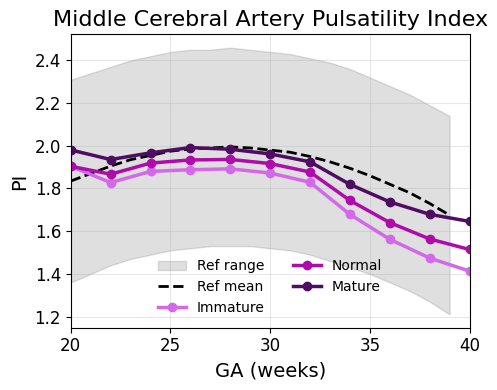

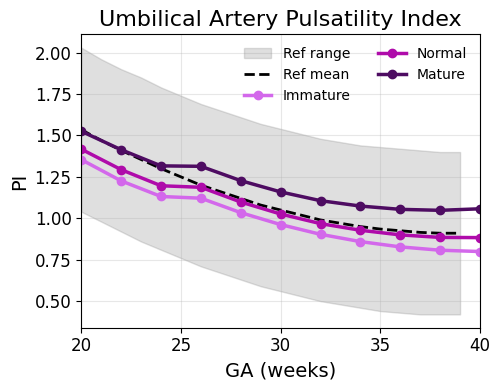

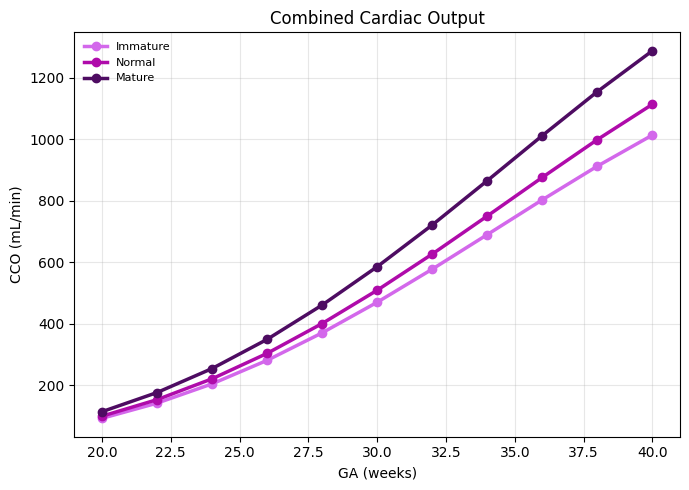

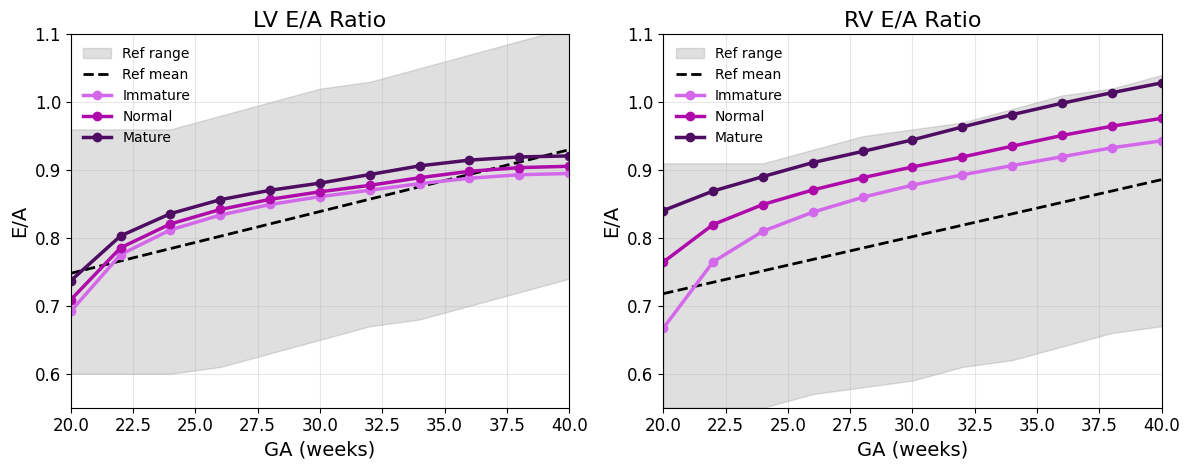

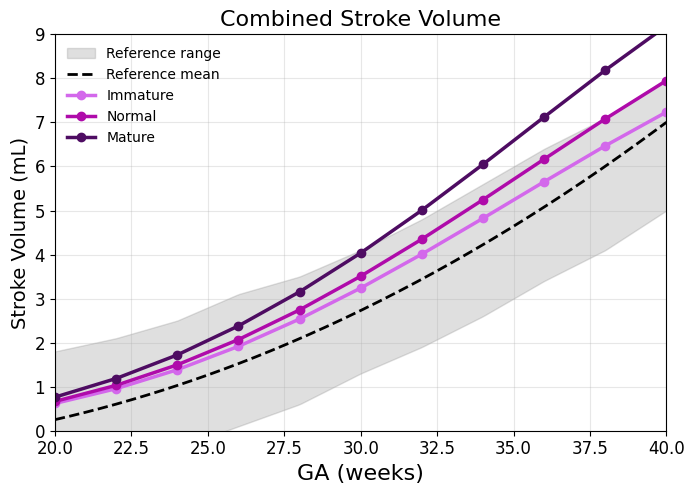

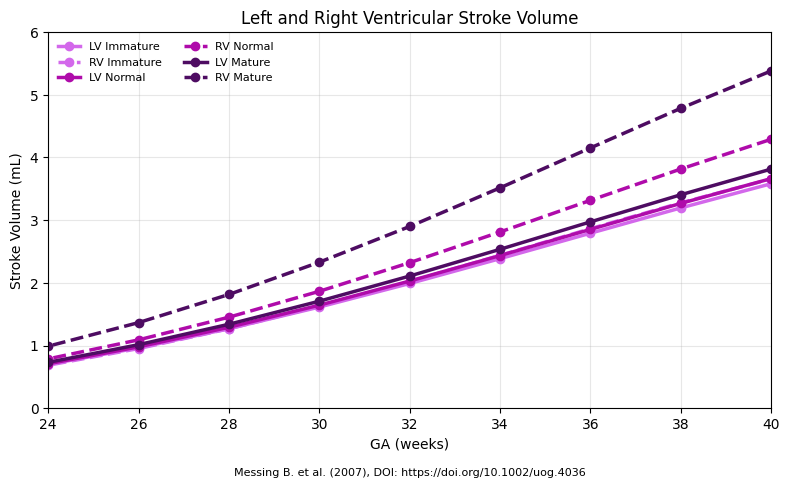

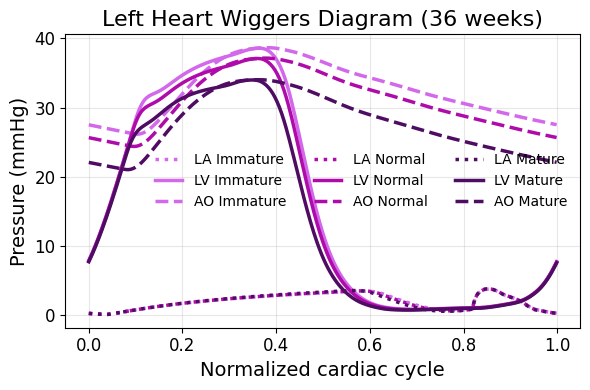

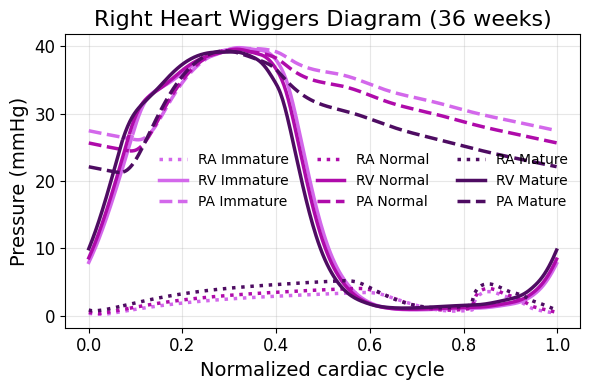

In [2]:

# ============================================================================
# PLOTTING RESULTS
# ============================================================================
# =====================================================
# COLORS FOR PERCENTILES
# =====================================================

MATURITY_COLORS = {
	"immature": "#D368EB",   # light purple
	"normal":   "#AF0BAA",   # medium purple
	"mature":   "#4E0C62"    # dark purple
}

MATURITY_LABELS = {
	"immature": "Immature",
	"normal": "Normal",
	"mature": "Mature"
}


with PdfPages("fetal_results_MODEL_VAR_brain.pdf") as pdf:

	# ======================
	# PI MCA - Variability
	# ======================

	plt.figure(figsize=(5, 4))

	weeks_ref = np.arange(20, 40)

	mca_low = np.array([
		1.36,1.40,1.44,1.47,1.49,1.51,1.52,1.53,1.53,1.53,
		1.52,1.51,1.49,1.46,1.43,1.40,1.36,1.32,1.27,1.21
	])

	mca_high = np.array([
		2.31,2.34,2.37,2.4,2.42,2.44,2.45,2.45,2.46,2.45,
		2.44,2.43,2.41,2.39,2.36,2.32,2.28,2.24,2.19,2.14
	])

	mca_mean = (mca_low + mca_high) / 2

	# Reference range
	plt.fill_between(
		weeks_ref,
		mca_low,
		mca_high,
		color="gray",
		alpha=0.25,
		label="Ref range"
	)

	# Reference mean
	plt.plot(
		weeks_ref,
		mca_mean,
		"k--",
		lw=2,
		label="Ref mean"
	)

	# Model results
	for mat in ["immature", "normal", "mature"]:

		dfm = df_var[df_var["Maturity"] == mat]

		plt.plot(
			dfm["GA"],
			dfm["PI_MCA"],
			"-o",
			color=MATURITY_COLORS[mat],
			linewidth=2.5,
			markersize=6,
			label=MATURITY_LABELS[mat]
		)

	plt.title("Middle Cerebral Artery Pulsatility Index", fontsize=16)
	plt.xlabel("GA (weeks)", fontsize=14)
	plt.ylabel("PI", fontsize=14)
	plt.xlim(20,40)

	plt.grid(alpha=0.3)
	plt.legend(
		fontsize=10,
		ncol=2,
		frameon=False
	)
	plt.tick_params(axis='both', labelsize=12)

	ax = plt.gca()

	plt.tight_layout()

	pdf.savefig()
	plt.show()
	plt.close()

	# ======================
	# PI UA - Variability
	# ======================

	plt.figure(figsize=(5, 4))

	weeks_ref = np.arange(20, 40)

	ua_low = np.array([
		1.04,0.98,0.92,0.86,0.81,0.76,0.71,0.67,0.63,0.59,
		0.56,0.53,0.50,0.48,0.46,0.44,0.43,0.42,0.42,0.42
	])

	ua_high = np.array([
		2.03,1.96,1.90,1.85,1.79,1.74,1.69,1.65,1.61,1.57,
		1.54,1.51,1.48,1.46,1.44,1.43,1.42,1.41,1.40,1.40
	])

	ua_mean = (ua_low + ua_high) / 2

	# Reference range
	plt.fill_between(
		weeks_ref,
		ua_low,
		ua_high,
		color="gray",
		alpha=0.25,
		label="Ref range"
	)

	# Reference mean
	plt.plot(
		weeks_ref,
		ua_mean,
		"k--",
		lw=2,
		label="Ref mean"
	)

	# Model results
	for mat in ["immature", "normal", "mature"]:

		dfm = df_var[df_var["Maturity"] == mat]

		plt.plot(
			dfm["GA"],
			dfm["PI_UA"],
			"-o",
			color=MATURITY_COLORS[mat],
			linewidth=2.5,
			markersize=6,
			label=MATURITY_LABELS[mat]
		)

	plt.title("Umbilical Artery Pulsatility Index", fontsize=16)
	plt.xlabel("GA (weeks)", fontsize=14)
	plt.ylabel("PI", fontsize=14)
	plt.tick_params(axis='both', labelsize=12)
	plt.xlim(20,40)

	plt.grid(alpha=0.3)

	plt.legend(
		fontsize=10,
		ncol=2,
		frameon=False
	)

	plt.tight_layout()

	pdf.savefig()
	plt.show()
	plt.close()


	# ======================
	# Combined Cardiac Output - Variability
	# ======================

	plt.figure(figsize=(7, 5))

	for mat in ["immature", "normal", "mature"]:

		dfm = df_var[df_var["Maturity"] == mat]

		plt.plot(
			dfm["GA"],
			dfm["CCO"],
			"-o",
			color=MATURITY_COLORS[mat],
			linewidth=2.5,
			markersize=6,
			label=MATURITY_LABELS[mat]
		)

	plt.title("Combined Cardiac Output")
	plt.xlabel("GA (weeks)")
	plt.ylabel("CCO (mL/min)")

	plt.grid(alpha=0.3)

	plt.legend(
		fontsize=8,
		frameon=False
	)

	plt.tight_layout()

	pdf.savefig()
	plt.show()
	plt.close()

	# ======================
	# E/A Ratio - Variability
	# ======================

	fig, ax = plt.subplots(1, 2, figsize=(12, 5))
	GA_list_ref = np.array([24,26,28,30,32,34,36,38,40])

	GA_days = np.array(GA_list) * 7

	ea_lv_ref = 0.566 + 0.0013 * GA_days
	ea_rv_ref = 0.550 + 0.0012 * GA_days

	ea_p95_lv = np.array([0.96,0.98,1.00,1.02,1.03,1.05,1.07,1.09,1.11])
	ea_p5_lv  = np.array([0.60,0.61,0.63,0.65,0.67,0.68,0.70,0.72,0.74])

	ea_p95_rv = np.array([0.91,0.93,0.95,0.96,0.97,0.99,1.01,1.02,1.04])
	ea_p5_rv  = np.array([0.55,0.57,0.58,0.59,0.61,0.62,0.64,0.66,0.67])
	
	ea_p95_lv_i = np.interp(GA_list, GA_list_ref, ea_p95_lv)
	ea_p5_lv_i  = np.interp(GA_list, GA_list_ref, ea_p5_lv)

	ea_p95_rv_i = np.interp(GA_list, GA_list_ref, ea_p95_rv)
	ea_p5_rv_i  = np.interp(GA_list, GA_list_ref, ea_p5_rv)

	# ---------- LV ----------

	ax[0].fill_between(
		GA_list,
		ea_p5_lv_i,
		ea_p95_lv_i,
		color="gray",
		alpha=0.25,
		label="Ref range"
	)

	ax[0].plot(
		GA_list,
		ea_lv_ref,
		"k--",
		lw=2,
		label="Ref mean"
	)

	for mat in ["immature", "normal", "mature"]:

		dfm = df_var[df_var["Maturity"] == mat]

		ax[0].plot(
			dfm["GA"],
			dfm["EA_LV"],
			"-o",
			color=MATURITY_COLORS[mat],
			linewidth=2.5,
			markersize=6,
			label=MATURITY_LABELS[mat]
		)

	ax[0].set_title("LV E/A Ratio", fontsize=16)
	ax[0].set_xlabel("GA (weeks)", fontsize=14)
	ax[0].set_ylabel("E/A", fontsize=14)
	ax[0].set_ylim(0.55, 1.10)
	ax[0].set_xlim(20,40)
	ax[0].tick_params(axis='both', labelsize=12)
	ax[0].grid(alpha=0.3)
	ax[0].legend(
		fontsize=10,
		frameon=False,
		loc='upper left'
	)

	# ---------- RV ----------

	ax[1].fill_between(
		GA_list,
		ea_p5_rv_i,
		ea_p95_rv_i,
		color="gray",
		alpha=0.25,
		label="Ref range"
	)

	ax[1].plot(
		GA_list,
		ea_rv_ref,
		"k--",
		lw=2,
		label="Ref mean"
	)

	for mat in ["immature", "normal", "mature"]:

		dfm = df_var[df_var["Maturity"] == mat]

		ax[1].plot(
			dfm["GA"],
			dfm["EA_RV"],
			"-o",
			color=MATURITY_COLORS[mat],
			linewidth=2.5,
			markersize=6,
			label=MATURITY_LABELS[mat]
		)

	ax[1].set_title("RV E/A Ratio", fontsize=16)
	ax[1].set_xlabel("GA (weeks)", fontsize=14)
	ax[1].set_ylabel("E/A", fontsize=14)
	ax[1].set_ylim(0.55, 1.10)
	ax[1].set_xlim(20,40)
	ax[1].tick_params(axis='both', labelsize=12)
	ax[1].grid(alpha=0.3)
	ax[1].legend(
		fontsize=10,
		frameon=False
	)
	'''
	fig.text(
		0.5,
		0.01,
		"Comas M. et al. (2011), DOI: https://doi.org/10.1002/uog.8870",
		ha="center",
		fontsize=8
	)
	'''
	plt.tight_layout(rect=[0,0.04,1,1])

	pdf.savefig()
	plt.show()
	plt.close()

	# ======================
	# Stroke Volume - Variability
	# ======================

	GA_ref = np.linspace(20, 40, 200)   
	GA_list_ref = np.array([20, 22, 24, 26, 28, 30, 32, 34, 36, 38, 40])

	GA_mean_pts = np.array([
		20, 21, 22, 23, 24, 26, 28, 30, 32,
		34, 36, 38, 40
	])

	SV_mean_pts = np.array([
		0.30, 0.45, 0.65, 0.80, 0.90,
		1.50, 2.00, 2.70, 3.50,
		4.30, 5.20, 6.00, 6.90
	])

	# 5th percentile
	SV_p5_pts = np.array([
		-1.2, -0.8, -0.4, 0.1, 0.60,
		1.3, 1.90, 2.6, 3.40, 4.10, 5.0
	])

	# 95th percentile
	SV_p95_pts = np.array([
		1.8, 2.1, 2.5, 3.1, 3.5,
		4.1, 4.80, 5.60, 6.40, 7.10, 8.0
	])

	coef_mean = np.polyfit(GA_mean_pts, SV_mean_pts, 2)

	sv_mean = np.polyval(coef_mean, GA_ref)
	sv_p5 = np.interp(GA_ref,GA_list_ref,SV_p5_pts)
	sv_p95 = np.interp(GA_ref,GA_list_ref,SV_p95_pts)

	# ======================
	# Combined Stroke Volume
	# ======================

	plt.figure(figsize=(7, 5))

	plt.fill_between(
		GA_ref,
		sv_p5,
		sv_p95,
		color="gray",
		alpha=0.25,
		label="Reference range"
	)

	plt.plot(
		GA_ref,
		sv_mean,
		"k--",
		lw=2,
		label="Reference mean"
	)

	for mat in ["immature", "normal", "mature"]:

		dfm = df_var[df_var["Maturity"] == mat]

		plt.plot(
			dfm["GA"],
			dfm["C_SV"],
			"-o",
			color=MATURITY_COLORS[mat],
			linewidth=2.5,
			markersize=6,
			label=MATURITY_LABELS[mat]
		)

	plt.xlabel("GA (weeks)", fontsize=16)
	plt.ylabel("Stroke Volume (mL)", fontsize=14)
	plt.title("Combined Stroke Volume", fontsize=16)

	plt.xlim(20, 40)
	plt.ylim(0, 9)

	plt.grid(alpha=0.3)

	plt.legend(
		fontsize=10,
		frameon=False
	)

	ax = plt.gca()
	'''
	ax.text(
		0.5,
		-0.18,
		"Messing B. et al. (2007), DOI: https://doi.org/10.1002/uog.4036",
		transform=ax.transAxes,
		ha="center",
		fontsize=8
	)
	'''
	plt.tight_layout()
	plt.tick_params(axis='both', labelsize=12)

	pdf.savefig()
	plt.show()
	plt.close()
	
	# ======================
	# LV and RV Stroke Volume
	# ======================

	plt.figure(figsize=(8, 5))

	for mat in ["immature", "normal", "mature"]:

		dfm = df_var[df_var["Maturity"] == mat]

		# LV
		plt.plot(
			dfm["GA"],
			dfm["SV_LV"],
			"-o",
			color=MATURITY_COLORS[mat],
			linewidth=2.5,
			markersize=6,
			label=f"LV {MATURITY_LABELS[mat]}"
		)

		# RV
		plt.plot(
			dfm["GA"],
			dfm["SV_RV"],
			"--o",
			color=MATURITY_COLORS[mat],
			linewidth=2.5,
			markersize=6,
			label=f"RV {MATURITY_LABELS[mat]}"
		)

	plt.xlabel("GA (weeks)")
	plt.ylabel("Stroke Volume (mL)")
	plt.title("Left and Right Ventricular Stroke Volume")

	plt.xlim(24, 40)
	plt.ylim(0, 6)

	plt.grid(alpha=0.3)

	plt.legend(
		fontsize=8,
		ncol=2,
		frameon=False
	)

	ax = plt.gca()

	ax.text(
		0.5,
		-0.18,
		"Messing B. et al. (2007), DOI: https://doi.org/10.1002/uog.4036",
		transform=ax.transAxes,
		ha="center",
		fontsize=8
	)

	plt.tight_layout()

	pdf.savefig()
	plt.show()
	plt.close()

	# ======================
	# Wiggers diagrams
	# ======================

	# ======================
	# Wiggers - Left Heart
	# ======================

	plt.figure(figsize=(6, 4))

	for mat in ["immature", "normal", "mature"]:

		data = results_var[(36, mat)]

		t = data["t_norm_align"].copy()

		jump = np.where(np.diff(t) < 0)[0][0] + 1

		t = np.insert(t, jump, np.nan)

		LA = np.insert(data["P_LA_align"], jump, np.nan)
		LV = np.insert(data["P_LV_align"], jump, np.nan)
		AO = np.insert(data["P_AO_align"], jump, np.nan)

		plt.plot(
			t,
			LA,
			":",
			color=MATURITY_COLORS[mat],
			linewidth=2.5,
			label=f"LA {MATURITY_LABELS[mat]}"
		)

		plt.plot(
			t,
			LV,
			"-",
			color=MATURITY_COLORS[mat],
			linewidth=2.5,
			label=f"LV {MATURITY_LABELS[mat]}"
		)

		plt.plot(
			t,
			AO,
			"--",
			color=MATURITY_COLORS[mat],
			linewidth=2.5,
			label=f"AO {MATURITY_LABELS[mat]}"
		)

	plt.xlabel("Normalized cardiac cycle", fontsize=14)
	plt.ylabel("Pressure (mmHg)", fontsize=14)
	plt.title("Left Heart Wiggers Diagram (36 weeks)", fontsize=16)
	plt.tick_params(axis='both', labelsize=12)

	plt.grid(alpha=0.3)

	plt.legend(
		fontsize=10,
		ncol=3,
		frameon=False
	)

	plt.tight_layout()

	pdf.savefig()
	plt.show()
	plt.close()

	# ======================
	# Wiggers - Right Heart
	# ======================

	plt.figure(figsize=(6, 4))

	for mat in ["immature", "normal", "mature"]:

		data = results_var[(36, mat)]

		t = data["t_norm_align"].copy()

		jump = np.where(np.diff(t) < 0)[0][0] + 1

		t = np.insert(t, jump, np.nan)

		RA = np.insert(data["P_RA_align"], jump, np.nan)
		RV = np.insert(data["P_RV_align"], jump, np.nan)
		MPA = np.insert(data["P_MPA_align"], jump, np.nan)

		plt.plot(
			t,
			RA,
			":",
			color=MATURITY_COLORS[mat],
			linewidth=2.5,
			label=f"RA {MATURITY_LABELS[mat]}"
		)

		plt.plot(
			t,
			RV,
			"-",
			color=MATURITY_COLORS[mat],
			linewidth=2.5,
			label=f"RV {MATURITY_LABELS[mat]}"
		)

		plt.plot(
			t,
			MPA,
			"--",
			color=MATURITY_COLORS[mat],
			linewidth=2.5,
			label=f"PA {MATURITY_LABELS[mat]}"
		)

	plt.xlabel("Normalized cardiac cycle", fontsize=14)
	plt.ylabel("Pressure (mmHg)", fontsize=14)
	plt.title("Right Heart Wiggers Diagram (36 weeks)", fontsize=16)
	plt.tick_params(axis='both', labelsize=12)

	plt.grid(alpha=0.3)

	plt.legend(
		fontsize=10,
		ncol=3,
		frameon=False
	)

	plt.tight_layout()

	pdf.savefig()
	plt.show()
	plt.close()
